
# Lab1_3: PDE

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Read
path = 'users/lucasperdomo/Fisica_Computacional_1/Sesiones/PDE/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'


#### **Exercise 1**: Lab1_3: finite-differences with tolerance **Jacobi method**


SOlve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
2. Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.

#### **Exercise 2**: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

In [18]:
# Solucionando los ejercicios propuestos a laboratorio tenemos:

# Ejercicio 1: 

def Laplace(V_0, tol, x, y):

    Nmax = V_0.shape[0]
    V_old = V_0.copy()
    V_new = V_0.copy()

    M_Diferencia = float('inf')
    contador = 0 

    while M_Diferencia > tol:
        V_old = V_new.copy()

        for i in range(1, Nmax-1):
            for j in range(1, Nmax-1):
                V_new [i,j] = 0.25 * (V_old[i+1,j] + V_old[i-1,j] + V_old[i, j+1] + V_old[i, j-1])

        M_Diferencia = np.max(np.abs(V_new - V_old))
        contador += 1

    print(f'Hubo convergencia en la iteración {contador} con una diferencia máxima de {M_Diferencia:.6f}')

    X,Y = np.meshgrid(x,y)
    Z = V_new[X,Y]

    return X, Y, Z


In [11]:
# Aplicando la función al Ejercicio 1 tenemos:

#  ondiciones deseadas:
Nmax = 100
tol = 10e-4

#Matriz inicial:
V_0 = np.zeros((Nmax,Nmax), float)
for k in range(0, Nmax):
    V_0[k,0] = 100  # condiciones de Frontera

# Creamos array de Coordenadas y aplicamos la Función Laplace:
x = np.arange(0, Nmax-1, 1)
y = x

X, Y, Z = Laplace(V_0, tol, x, y)

V_0    


Hubo convergencia en la iteración 5991 con una diferencia máxima de 0.001000


array([[100.,   0.,   0., ...,   0.,   0.,   0.],
       [100.,   0.,   0., ...,   0.,   0.,   0.],
       [100.,   0.,   0., ...,   0.,   0.,   0.],
       ...,
       [100.,   0.,   0., ...,   0.,   0.,   0.],
       [100.,   0.,   0., ...,   0.,   0.,   0.],
       [100.,   0.,   0., ...,   0.,   0.,   0.]], shape=(100, 100))

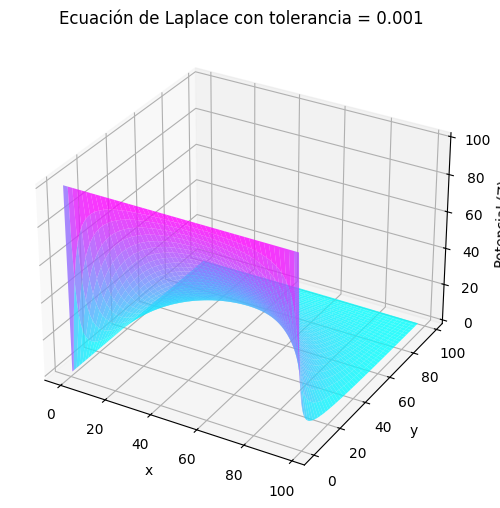

In [12]:
# Graficamos:

fig = plt.figure(figsize=(8,6))
ax_tol = fig.add_subplot(111, projection='3d') # Usar add_subplot en lugar de plt.axes
ax_tol.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax_tol.set_title(f'Ecuación de Laplace con tolerancia = {tol}')
ax_tol.set_xlabel('x')
ax_tol.set_ylabel('y')
ax_tol.set_zlabel('Potencial (Z)')
plt.show()


In [13]:
# HACIENDO COMPARACIÓN CON EL N-ESIMO MODO DE LA SERIE DE FOURIER TENEMOS:

def Fourier(x, y, n=1, L=1):
    v0 = 100
    x_arr = np.asarray(x)
    y_arr = np.asarray(y)

    return (4*v0/(n*np.pi))*np.sin(n*np.pi*x_arr/L)*np.sinh(n*np.pi*(L-y_arr)/L)/np.sinh(n*np.pi)

#Aplicamos el criterio de tolerancia:
Nmax = 100 
L = Nmax

#Configuramos Arrays:
x_coor = np.arange(0, Nmax-1, 1)
y_coor = np.arange(0, Nmax-1, 1) 

# Creamos Malla 2D para graficar:
X_grid, Y_grid = np.meshgrid(x_coor, y_coor)

# Inicializamos z como array 2D de ceros:
z = np.zeros_like(X_grid, dtype= float)


tol_f = 0.0009
max_diff_fourier = float('inf')
n_terms = 1 
contador = 0
N_max_terminos = 40000

print(f'La serie de Fourier con Tolerancia {tol_f} es: ')

while max_diff_fourier > tol_f and contador < N_max_terminos:
    z_old = z.copy()

    term_n = Fourier(X_grid, Y_grid, n = n_terms, L=L)
    z += term_n

    diff = np.abs(z - z_old)
    if np.any(np.isnan(diff)):
        max_diff_fourier = float('inf')
    else:
        max_diff_fourier = np.max(diff)

    n_terms += 2
    contador += 1


print(f'La serie de Fourier converge en {n_terms} terminos de Fourier con una Tolerancia = {tol_f}')




La serie de Fourier con Tolerancia 0.0009 es: 


/var/folders/59/nnw34xf134xb_z8xlds9n4sh0000gn/T/ipykernel_4143/767459779.py:8: RuntimeWarning: overflow encountered in sinh
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x_arr/L)*np.sinh(n*np.pi*(L-y_arr)/L)/np.sinh(n*np.pi)
/var/folders/59/nnw34xf134xb_z8xlds9n4sh0000gn/T/ipykernel_4143/767459779.py:8: RuntimeWarning: invalid value encountered in multiply
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x_arr/L)*np.sinh(n*np.pi*(L-y_arr)/L)/np.sinh(n*np.pi)
/var/folders/59/nnw34xf134xb_z8xlds9n4sh0000gn/T/ipykernel_4143/767459779.py:8: RuntimeWarning: invalid value encountered in divide
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x_arr/L)*np.sinh(n*np.pi*(L-y_arr)/L)/np.sinh(n*np.pi)


La serie de Fourier converge en 80001 terminos de Fourier con una Tolerancia = 0.0009


In [14]:
# Vemos que la serie tiene errores en las convergencias del seno hiperbólico y no nos da una matriz nula; por lo tanto, vamos a usar mejores aproximaciones asintóticas para sinh(a)/sinh(b)=exp(a-b)
# Reorganizando de nuevo el código:



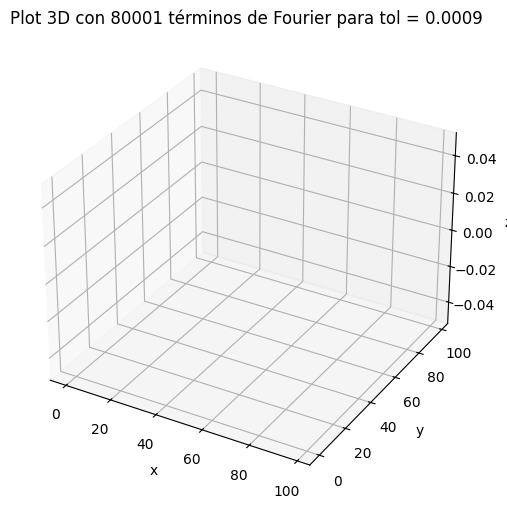

In [15]:
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d')
ax.plot_surface(X_grid, Y_grid, z, cmap= 'cool', alpha=0.8)
ax.set_title(f'Plot 3D con {n_terms} términos de Fourier para tol = {tol_f}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

Calculando serie de Fourier con tolerancia = 0.0009
Serie de Fourier convergida en 20000 términos (n máximo = 39999) con una diferencia máxima de 0.003183


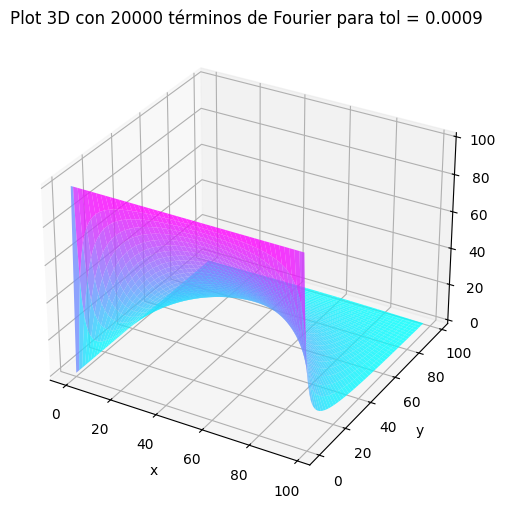

In [16]:
#Definir el n-ésimo modo
def un(x,y,n=1,L=1):
  'función para calcular el n-ésimo término de la serie de Fourier'
  v0 = 100 #Voltaje
  # Asegurar que x e y sean arrays de numpy para operaciones elemento a elemento
  x_arr = np.asarray(x)
  y_arr = np.asarray(y)

  # Calcular el argumento para las funciones sinh
  arg_numerator = n * np.pi * (L - y_arr) / L
  arg_denominator = n * np.pi

  # Utilizar una aproximación asintótica para sinh(a)/sinh(b) = exp(a-b) cuando los argumentos son grandes
  # Esto evita el desbordamiento (inf) y la división inf/inf = nan
  # El umbral se elige para que los argumentos grandes de sinh sean tratados asintóticamente
  threshold = np.log(np.finfo(float).max) - 10 # Un umbral seguro para evitar desbordamientos de exp o sinh

  if arg_denominator > threshold: # Si el denominador de sinh es grande, usar la aproximación exponencial
      ratio_sinh = np.exp(-n * np.pi * y_arr / L)
  else: # De lo contrario, calcular la relación exacta de sinh
      # Manejar el caso especial donde y_arr = L, lo que hace que arg_numerator sea 0
      # y np.sinh(0) = 0. En este caso, la función debe ser 0.
      # Si L-y_arr es muy pequeño (casi 0), arg_numerator será muy pequeño.
      # Para evitar 0/0 si arg_numerator y arg_denominator son pequeños, o inf/inf si ambos son grandes,
      # ya lo cubrimos con el threshold. Si arg_denominator no es grande, entonces
      # ambos sinh deberían ser calculables. Para y_arr=L, arg_numerator=0, sinh(0)=0, ratio=0.
      # Este enfoque general debería ser seguro.
      ratio_sinh = np.sinh(arg_numerator) / np.sinh(arg_denominator)

  return (4 * v0 / (n * np.pi)) * np.sin(n * np.pi * x_arr / L) * ratio_sinh

# --- Aplicar el criterio de tolerancia para la serie de Fourier ---

Nmax = 100 # Asumiendo Nmax de celdas anteriores (ej., configuración de Laplace2D_tolerance)
L = Nmax   # Longitud del dominio

# Crear arrays de coordenadas 1D (consistente con los arrays X_tol, Y_tol)
x_coords = np.arange(0, Nmax - 1, 1)
y_coords = np.arange(0, Nmax - 1, 1)

# Crear arrays de malla 2D para graficar
X_grid, Y_grid = np.meshgrid(x_coords, y_coords)

# Inicializar z como un array 2D de ceros con la forma correcta
z = np.zeros_like(X_grid, dtype=float)

tol_fourier = 0.0009 # La misma tolerancia que para diferencias finitas
max_diff_fourier = float('inf')
current_n = 1 # Empezamos con el primer término impar de la serie (n=1)
n_terms = 0 # Contador de términos sumados
N_max_fourier_terms_limit = 20000 # Un límite para evitar bucles infinitos en caso de no convergencia rápida

print(f"Calculando serie de Fourier con tolerancia = {tol_fourier}")

while max_diff_fourier > tol_fourier and n_terms < N_max_fourier_terms_limit:
  z_old = z.copy() # Guardar el estado actual antes de añadir el nuevo término

  # Añadir el término actual de la serie (solo n impares)
  term_n = un(X_grid, Y_grid, n=current_n, L=L)
  z += term_n

  # Calcular la máxima diferencia absoluta entre el estado nuevo y el viejo
  # Esto representa la contribución del último término añadido o el cambio total en la suma.
  # Excluir NaN de la comparación si term_n o z contienen NaNs por alguna razón inesperada
  valid_diff = np.abs(z - z_old)
  if np.any(np.isnan(valid_diff)):
      max_diff_fourier = float('inf') # Mantener iterando si hay NaNs
  else:
      max_diff_fourier = np.max(valid_diff)

  current_n += 2 # Pasar al siguiente número impar
  n_terms += 1

print(f"Serie de Fourier convergida en {n_terms} términos (n máximo = {current_n-2}) con una diferencia máxima de {max_diff_fourier:.6f}")

#Graficar el campo
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X_grid, Y_grid, z, cmap='cool', alpha=0.8)
ax.set_title(f'Plot 3D con {n_terms} términos de Fourier para tol = {tol_fourier}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()